# Phase 2 — Engineer & Transform Features
**ML Foundations Capstone | Ames Housing Dataset**

**Khaled Waleed Althobaiti | خالد وليد الثبيتي**
Class 1/1 | صف 1/1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

CLEAN_PATH   = '../data/raw/AmesHousing.csv'
FEATURE_PATH = '../data/cleaned/AmesHousing_features.csv'

## 0. Reload & Re-clean

In [2]:
def clean_data(df):
    df = df.copy()
    for col in ['MS SubClass', 'Mo Sold', 'Yr Sold']:
        df[col] = df[col].astype(str)
    df = df.drop_duplicates()
    none_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
                 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
                 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
                 'BsmtFin Type 1', 'BsmtFin Type 2', 'Mas Vnr Type']
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')
    zero_cols = ['Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
                 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
                 'Garage Cars', 'Garage Area', 'Garage Yr Blt']
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage']                            .transform(lambda x: x.fillna(x.median()))
    df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
    df['SalePrice'] = df['SalePrice'].clip(upper=df['SalePrice'].quantile(0.99))
    Q1, Q3 = df['Gr Liv Area'].quantile([0.25, 0.75])
    df['Gr Liv Area'] = df['Gr Liv Area'].clip(upper=Q3 + 3*(Q3-Q1))
    df = df.drop(columns=['Order', 'PID'], errors='ignore')
    return df

df = clean_data(pd.read_csv(CLEAN_PATH))
print(f"Loaded clean data: {df.shape}")

Loaded clean data: (2930, 80)


## 1. One-Hot Encoding (2 categorical columns)

`MS Zoning` tells us the land-use zone (residential, commercial etc.) and `Sale Condition` tells us whether the sale was normal or distressed. Both are nominal — no natural order — so one-hot encoding makes sense here.

In [3]:
df = pd.get_dummies(df, columns=['MS Zoning', 'Sale Condition'], drop_first=True)
print("After one-hot encoding:", df.shape)
new_ohe_cols = [c for c in df.columns if c.startswith('MS Zoning') or c.startswith('Sale Condition')]
print("New columns:", new_ohe_cols)

After one-hot encoding: (2930, 89)
New columns: ['MS Zoning_C (all)', 'MS Zoning_FV', 'MS Zoning_I (all)', 'MS Zoning_RH', 'MS Zoning_RL', 'MS Zoning_RM', 'Sale Condition_AdjLand', 'Sale Condition_Alloca', 'Sale Condition_Family', 'Sale Condition_Normal', 'Sale Condition_Partial']


## 2. Ordinal Encoding (1 ordered column)

The quality text columns (`Exter Qual`, `Kitchen Qual`, etc.) follow a clear order from Poor to Excellent. I mapped them to integers (0–5) so that order is preserved in any calculations.

In [4]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

for col in ['Exter Qual', 'Kitchen Qual', 'Bsmt Qual', 'Heating QC', 'Garage Qual']:
    if col in df.columns:
        df[col + '_Ord'] = df[col].map(qual_map).fillna(0).astype(int)
        df = df.drop(columns=[col])

print("Ordinal-encoded quality columns. Sample:")
print(df[['Exter Qual_Ord', 'Kitchen Qual_Ord', 'Bsmt Qual_Ord']].head())

Ordinal-encoded quality columns. Sample:
   Exter Qual_Ord  Kitchen Qual_Ord  Bsmt Qual_Ord
0               3                 3              3
1               3                 3              3
2               3                 4              3
3               4                 5              3
4               3                 3              4


## 3. Standard Scaling (2 numerical columns)

`Gr Liv Area` is in square feet and `Lot Area` is much larger in raw numbers. Scaling both to mean=0, std=1 makes them comparable — important for the cosine similarity task in Phase 3.

In [5]:
scaler = StandardScaler()

scale_cols = ['Gr Liv Area', 'Lot Area']
df[['Gr Liv Area_Scaled', 'Lot Area_Scaled']] = scaler.fit_transform(df[scale_cols])

print("Scaled stats:")
print(df[['Gr Liv Area_Scaled', 'Lot Area_Scaled']].describe().round(3))

Scaled stats:
       Gr Liv Area_Scaled  Lot Area_Scaled
count            2930.000         2930.000
mean               -0.000            0.000
std                 1.000            1.000
min                -2.360           -1.123
25%                -0.754           -0.344
50%                -0.112           -0.090
75%                 0.498            0.179
max                 4.251           26.032


## 4. Domain Features

### 4a. `price_per_sqft` — SalePrice ÷ Living Area

Raw price alone is misleading because bigger houses cost more just because of size. Price per square foot lets me compare houses of different sizes on equal footing.

In [6]:
total_sf = df['Gr Liv Area'].replace(0, np.nan)
df['price_per_sqft'] = df['SalePrice'] / total_sf
df['price_per_sqft'] = df['price_per_sqft'].fillna(df['price_per_sqft'].median())
print(f"price_per_sqft  mean=${df['price_per_sqft'].mean():.2f}  median=${df['price_per_sqft'].median():.2f}")

price_per_sqft  mean=$121.06  median=$120.23


### 4b. `total_bathrooms` — Combined bathroom count

The dataset has four separate bathroom columns (full bath, half bath, basement versions of each). I combined them into one number since that is how most buyers think about it.

In [7]:
df['total_bathrooms'] = (
    df['Full Bath'] +
    0.5 * df['Half Bath'] +
    df.get('Bsmt Full Bath', pd.Series(0, index=df.index)).fillna(0) +
    0.5 * df.get('Bsmt Half Bath', pd.Series(0, index=df.index)).fillna(0)
)
print(df['total_bathrooms'].value_counts().sort_index())

total_bathrooms
1.0    443
1.5    293
2.0    911
2.5    560
3.0    378
3.5    289
4.0     31
4.5     17
5.0      3
6.0      2
7.0      3
Name: count, dtype: int64


## 5. Interaction Feature — `qual_x_area`

A big house that is also high quality should be worth more than a big-but-average house or a small-but-excellent one. Multiplying the two captures that combined effect.

In [8]:
df['qual_x_area'] = df['Overall Qual'] * df['Gr Liv Area']
print(df[['Overall Qual', 'Gr Liv Area', 'qual_x_area', 'SalePrice']].head())

   Overall Qual  Gr Liv Area  qual_x_area  SalePrice
0             6         1656         9936   215000.0
1             5          896         4480   105000.0
2             6         1329         7974   172000.0
3             7         2110        14770   244000.0
4             5         1629         8145   189900.0


## 6. Log-Transform — `SalePrice`

The price distribution has a long right tail (a few very expensive homes). Taking the log pulls those in and makes the distribution much more symmetric, which is better for comparing and modelling.

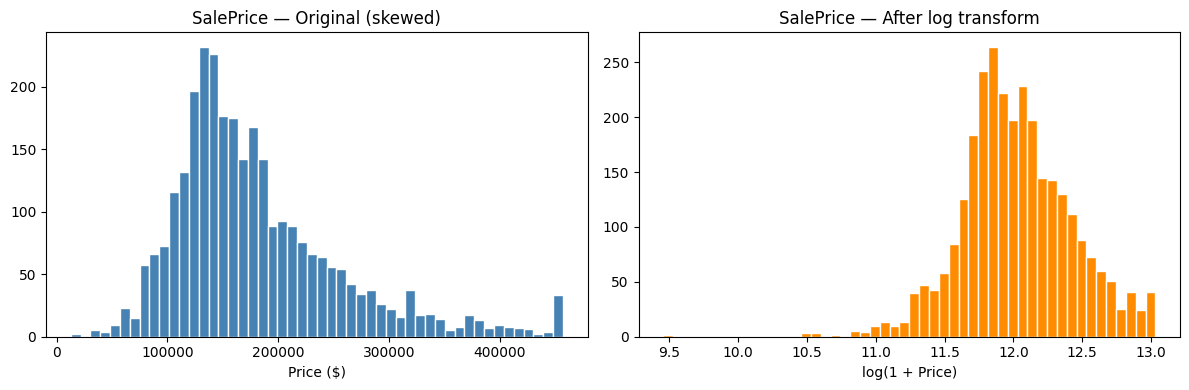

Original skewness:    1.310
After log transform:  -0.100


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice — Original (skewed)')
axes[0].set_xlabel('Price ($)')

df['SalePrice_Log'] = np.log1p(df['SalePrice'])

axes[1].hist(df['SalePrice_Log'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('SalePrice — After log transform')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.savefig('../data/cleaned/log_transform_comparison.png', dpi=150)
plt.show()

print(f"Original skewness:    {df['SalePrice'].skew():.3f}")
print(f"After log transform:  {df['SalePrice_Log'].skew():.3f}")

## 7. Binning — `house_age_group`

The exact year a house was built is noisy. Grouping into broad eras (Historic / Older / Mid-Century / Modern / Recent) captures the patterns buyers actually care about without overfitting to specific years.

In [10]:
bins   = [0, 1940, 1960, 1980, 2000, 2025]
labels = ['Historic', 'Older', 'Mid-Century', 'Modern', 'Recent']
df['house_age_group'] = pd.cut(df['Year Built'], bins=bins, labels=labels)

print(df['house_age_group'].value_counts().sort_index())

house_age_group
Historic       517
Older          492
Mid-Century    711
Modern         475
Recent         735
Name: count, dtype: int64


## 8. Remove Highly Correlated Features (r > 0.95)

If two columns are almost perfectly correlated one of them is redundant. I checked all numeric pairs and dropped one from any pair above 0.95.

In [11]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[num_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [(col, row) for col in upper.columns
                   for row in upper.index if upper.loc[row, col] > 0.95]

print("Highly correlated pairs (r > 0.95):")
for a, b in high_corr_pairs:
    print(f"  {a}    {b}  (r={corr_matrix.loc[a,b]:.3f})")

to_drop = list(set([b for _, b in high_corr_pairs]))
df = df.drop(columns=[c for c in to_drop if c in df.columns], errors='ignore')
print(f"\nDropped: {to_drop}")
print(f"Final shape: {df.shape}")

Highly correlated pairs (r > 0.95):
  Gr Liv Area_Scaled    Gr Liv Area  (r=1.000)
  Lot Area_Scaled    Lot Area  (r=1.000)
  SalePrice_Log    SalePrice  (r=0.955)

Dropped: ['Gr Liv Area', 'Lot Area', 'SalePrice']
Final shape: (2930, 93)


## 9. Save

In [12]:
df.to_csv(FEATURE_PATH, index=False)
print(f"Saved -> {FEATURE_PATH}")
print(f"Total features: {df.shape[1]}")

Saved -> ../data/cleaned/AmesHousing_features.csv
Total features: 93
